## 베이스라인 결과 분석

### 데이터 구성

| Split | 행 수 | 시즌 |
|---|---|---|
| Train | 13,816 | 2021~2023 |
| Val | 4,651 | 2024 |
| Test | 4,674 | 2025 |

- Feature 수: 29개 (전처리 없음, NaN 모델 내부 처리)

---

### 성능 요약

| 모델 | Train RMSE | Val RMSE | Test RMSE | Val R² | Test R² |
|---|---|---|---|---|---|
| XGBoost | 0.1354 | 0.1363 | 0.1370 | 0.0050 | 0.0018 |
| CatBoost | 0.1350 | 0.1361 | 0.1368 | 0.0085 | 0.0053 |

---

### 주요 관찰

**1. Early stopping 효과 확인**
- XGBoost best iteration = **11** (500 중 11에서 조기 종료)
- 기존(early stopping 없음): Train R²=0.61 / Val R²=-0.05 → 심각한 과적합
- early stopping 후: Train R²=0.04 / Val R²=0.005 → 과적합 해소
- CatBoost best iteration = **80** (일관된 결과)

**2. 전반적인 R² 해석**
- 두 모델 모두 Val/Test R² ≈ 0.005~0.009로 매우 낮음
- **베이스라인으로서 예상된 결과**: 전처리 없음 + delta feature 미완성 + biomechanical feature 미포함
- wOBA는 수비 운·상대 타자 수준 등 외부 노이즈가 크기 때문에 R²가 낮게 나오는 것은 자연스러움
- **이후 실험의 기준점으로 사용** (RMSE: ~0.136, R²: ~0.005~0.009)

**3. SHAP Feature Importance 해석**
- 상위 feature: `avg_spin_Fastball` > `avg_speed_Fastball` > `avg_spin_Breaking`
- **절대값(avg_*)이 delta feature보다 상위** → 모델이 컨디션 변화보다 선수 스타일을 보고 있음
- `delta_speed_Fastball`은 중하위권 → delta feature 확장(spin, ext 포함) 시 개선 가능성
- `prev_speed_Offspeed`가 상위 4위 → 직전 시즌 기준값 자체도 예측에 기여 중

**4. 예측값 분포 (Scatter)**
- 예측값이 **0.30~0.35 구간에 극도로 몰림** → 모델이 평균으로 회귀하는 중
- 실제 wOBA 극단값(0.0~0.2, 0.6~1.0)을 전혀 예측하지 못함
- 경기 단위 wOBA의 분산이 크고 노이즈가 많기 때문

---

### 다음 단계 (Phase 2)

| 과제 | 근거 |
|---|---|
| delta feature 확장 (spin, ext 추가) | SHAP에서 절대값이 상위 → 편차 feature 강화 필요 |
| NaN 처리 전략 비교 | delta_speed_Offspeed NaN 54.7% 방치 중 |
| X 구간 실험 | batter9 외 inning2 / pitch15 비교 |
| biomechanical feature 추가 | 정형만으로는 R² 한계 명확 |

# 04. 베이스라인 모델링 (정형 데이터)
- 03_feature_engineering.ipynb 완료 후 실행
- **전처리 없이 날것 그대로** XGBoost / CatBoost 적합 (이후 실험의 비교 기준)
- NaN: 모델 내부 처리 그대로 (별도 imputation 없음)
- Early stopping만 추가하여 공정한 기준점 확보
- Train: 2021~2023 / Val: 2024 / Test: 2025

In [1]:
# ── 환경 감지 ──────────────────────────────────────────────
import os

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
else:
    DRIVE = os.path.dirname(os.path.abspath('__file__'))

FEATURE_DIR = os.path.join(DRIVE, '0_data', '4_features')
MODEL_DIR   = os.path.join(DRIVE, '4_output')
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'환경      : {"코랩" if IN_COLAB else "로컬"}')
print(f'FEATURE   : {FEATURE_DIR}')
print(f'MODEL     : {MODEL_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경      : 코랩
FEATURE   : /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features
MODEL     : /content/drive/MyDrive/투수 컨디션 예측 ML/4_output


In [2]:
import pandas as pd

try:
    import xgboost as xgb
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

try:
    import catboost
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'catboost', '-q'])
    import catboost

try:
    import shap
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'XGBoost  : {xgb.__version__}')
print(f'CatBoost : {catboost.__version__}')

XGBoost  : 3.2.0
CatBoost : 1.2.10


In [3]:
# ── 패키지 ─────────────────────────────────────────────────
import pandas as pd
import numpy as np

try:
    import xgboost as xgb
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

try:
    import catboost
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'catboost', '-q'])
    import catboost

try:
    import shap
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'XGBoost  : {xgb.__version__}')
print(f'CatBoost : {catboost.__version__}')

XGBoost  : 3.2.0
CatBoost : 1.2.10


## 1. 데이터 로드

In [4]:
# ── features_batter9.parquet 로드 ───────────────────────────
feat_path = os.path.join(FEATURE_DIR, 'features_batter9.parquet')
df = pd.read_parquet(feat_path)

print(f'전체: {len(df):,}행  |  컬럼: {len(df.columns)}')
print(f'시즌별 샘플 수:')
print(df['season'].value_counts().sort_index())
df.head()

전체: 23,141행  |  컬럼: 63
시즌별 샘플 수:
season
2021    4575
2022    4647
2023    4594
2024    4651
2025    4674
Name: count, dtype: int64


,game_pk,pitcher,season,total_pitches,avg_speed_all,std_speed_all,strike_ratio,fastball_ratio,breaking_ratio,offspeed_ratio,...,delta_ext_Fastball,delta_ext_Breaking,delta_ext_Offspeed,delta_pos_x_Fastball,delta_pos_x_Breaking,delta_pos_x_Offspeed,delta_pos_z_Fastball,delta_pos_z_Breaking,delta_pos_z_Offspeed,y_woba
0,633793,664285,2021,9,85.544444,7.755016,0.444444,0.555556,0.444444,0.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.2269
1,633788,592662,2021,16,92.787500,2.600224,0.625000,0.500000,0.500000,0.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.2667
2,633788,607074,2021,19,89.742105,5.194261,0.526316,0.421053,0.263158,0.315789,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.3559
3,633778,669456,2021,23,87.856522,4.578887,0.478261,0.434783,0.565217,0.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.2714
4,633777,605200,2021,25,86.520000,3.125567,0.400000,0.840000,0.000000,0.160000,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0600


In [5]:
# ── 컬럼 구성 확인 ──────────────────────────────────────────
print('전체 컬럼:')
for c in df.columns:
    print(f'  {c:<40} dtype={df[c].dtype}  NaN={df[c].isna().mean():.1%}')

전체 컬럼:
  game_pk                                  dtype=int64  NaN=0.0%
  pitcher                                  dtype=int64  NaN=0.0%
  season                                   dtype=int64  NaN=0.0%
  total_pitches                            dtype=int64  NaN=0.0%
  avg_speed_all                            dtype=float64  NaN=0.0%
  std_speed_all                            dtype=float64  NaN=0.0%
  strike_ratio                             dtype=float64  NaN=0.0%
  fastball_ratio                           dtype=float64  NaN=0.0%
  breaking_ratio                           dtype=float64  NaN=0.0%
  offspeed_ratio                           dtype=float64  NaN=0.0%
  avg_pos_x                                dtype=float64  NaN=0.0%
  avg_pos_z                                dtype=float64  NaN=0.0%
  avg_ext                                  dtype=float64  NaN=0.1%
  avg_arm_angle                            dtype=float64  NaN=0.7%
  avg_ext_Breaking                         dtype=float64  NaN=1

## 2. Train / Val / Test 분리

In [6]:
META_COLS    = ['game_pk', 'pitcher', 'season', 'y_woba']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

train = df[df['season'].isin([2021, 2022, 2023])].copy()
val   = df[df['season'] == 2024].copy()
test  = df[df['season'] == 2025].copy()

X_train = train[FEATURE_COLS]
y_train = train['y_woba']
X_val   = val[FEATURE_COLS]
y_val   = val['y_woba']
X_test  = test[FEATURE_COLS]
y_test  = test['y_woba']

print(f'Train : {len(train):,}행')
print(f'Val   : {len(val):,}행')
print(f'Test  : {len(test):,}행')
print(f'Feature 수: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Train : 13,816행
Val   : 4,651행
Test  : 4,674행
Feature 수: 59
['total_pitches', 'avg_speed_all', 'std_speed_all', 'strike_ratio', 'fastball_ratio', 'breaking_ratio', 'offspeed_ratio', 'avg_pos_x', 'avg_pos_z', 'avg_ext', 'avg_arm_angle', 'avg_ext_Breaking', 'avg_ext_Fastball', 'avg_ext_Offspeed', 'avg_pos_x_Breaking', 'avg_pos_x_Fastball', 'avg_pos_x_Offspeed', 'avg_pos_z_Breaking', 'avg_pos_z_Fastball', 'avg_pos_z_Offspeed', 'avg_speed_Breaking', 'avg_speed_Fastball', 'avg_speed_Offspeed', 'avg_spin_Breaking', 'avg_spin_Fastball', 'avg_spin_Offspeed', 'std_speed_Breaking', 'std_speed_Fastball', 'std_speed_Offspeed', 'prev_speed_Fastball', 'prev_speed_Breaking', 'prev_speed_Offspeed', 'prev_spin_Fastball', 'prev_spin_Breaking', 'prev_spin_Offspeed', 'prev_ext_Fastball', 'prev_ext_Breaking', 'prev_ext_Offspeed', 'prev_pos_x_Fastball', 'prev_pos_x_Breaking', 'prev_pos_x_Offspeed', 'prev_pos_z_Fastball', 'prev_pos_z_Breaking', 'prev_pos_z_Offspeed', 'delta_speed_Fastball', 'delta_speed_Brea

## 3. XGBoost

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
    early_stopping_rounds = 50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set       = [(X_val, y_val)],
    verbose        = 50,
)

print('XGBoost 학습 완료')
print(f'best iteration: {xgb_model.best_iteration}')

[0]	validation_0-rmse:0.13668
[50]	validation_0-rmse:0.13632
[78]	validation_0-rmse:0.13649
XGBoost 학습 완료
best iteration: 28


In [8]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    rmse = mean_squared_error(y, pred) ** 0.5
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    print(f'[{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2}

results = []
results.append(evaluate('XGB  Train', xgb_model, X_train, y_train))
results.append(evaluate('XGB  Val  ', xgb_model, X_val,   y_val))
results.append(evaluate('XGB  Test ', xgb_model, X_test,  y_test))

[XGB  Train]  RMSE=0.1319  MAE=0.1034  R2=0.0930
[XGB  Val  ]  RMSE=0.1362  MAE=0.1074  R2=0.0074
[XGB  Test ]  RMSE=0.1374  MAE=0.1089  R2=-0.0043


## 4. CatBoost

In [9]:
cb_model = CatBoostRegressor(
    iterations   = 500,
    learning_rate= 0.05,
    depth        = 6,
    random_seed  = 42,
    verbose      = 50,
)

cb_model.fit(
    X_train, y_train,
    eval_set = (X_val, y_val),
)

print('CatBoost 학습 완료')

0:	learn: 0.1384605	test: 0.1366828	best: 0.1366828 (0)	total: 85.1ms	remaining: 42.5s
50:	learn: 0.1358555	test: 0.1362542	best: 0.1362370 (35)	total: 1.04s	remaining: 9.14s
100:	learn: 0.1342537	test: 0.1362943	best: 0.1362126 (71)	total: 1.97s	remaining: 7.77s
150:	learn: 0.1328934	test: 0.1364512	best: 0.1362126 (71)	total: 2.88s	remaining: 6.65s
200:	learn: 0.1314947	test: 0.1365756	best: 0.1362126 (71)	total: 3.78s	remaining: 5.62s
250:	learn: 0.1300702	test: 0.1367054	best: 0.1362126 (71)	total: 4.68s	remaining: 4.64s
300:	learn: 0.1285720	test: 0.1368926	best: 0.1362126 (71)	total: 5.59s	remaining: 3.7s
350:	learn: 0.1270296	test: 0.1370277	best: 0.1362126 (71)	total: 6.51s	remaining: 2.76s
400:	learn: 0.1255692	test: 0.1371391	best: 0.1362126 (71)	total: 7.76s	remaining: 1.92s
450:	learn: 0.1241510	test: 0.1374282	best: 0.1362126 (71)	total: 9.47s	remaining: 1.03s
499:	learn: 0.1228589	test: 0.1375199	best: 0.1362126 (71)	total: 11.1s	remaining: 0us

bestTest = 0.1362125672
be

In [10]:
results.append(evaluate('CB   Train', cb_model, X_train, y_train))
results.append(evaluate('CB   Val  ', cb_model, X_val,   y_val))
results.append(evaluate('CB   Test ', cb_model, X_test,  y_test))

[CB   Train]  RMSE=0.1351  MAE=0.1058  R2=0.0487
[CB   Val  ]  RMSE=0.1362  MAE=0.1071  R2=0.0069
[CB   Test ]  RMSE=0.1369  MAE=0.1083  R2=0.0035


## 5. 결과 요약

In [11]:
summary = pd.DataFrame(results)
print(summary.to_string(index=False))

      name     rmse      mae        r2
XGB  Train 0.131942 0.103449  0.093037
XGB  Val   0.136177 0.107358  0.007407
XGB  Test  0.137434 0.108928 -0.004318
CB   Train 0.135126 0.105832  0.048730
CB   Val   0.136213 0.107145  0.006891
CB   Test  0.136896 0.108289  0.003533


## 6. SHAP Feature Importance

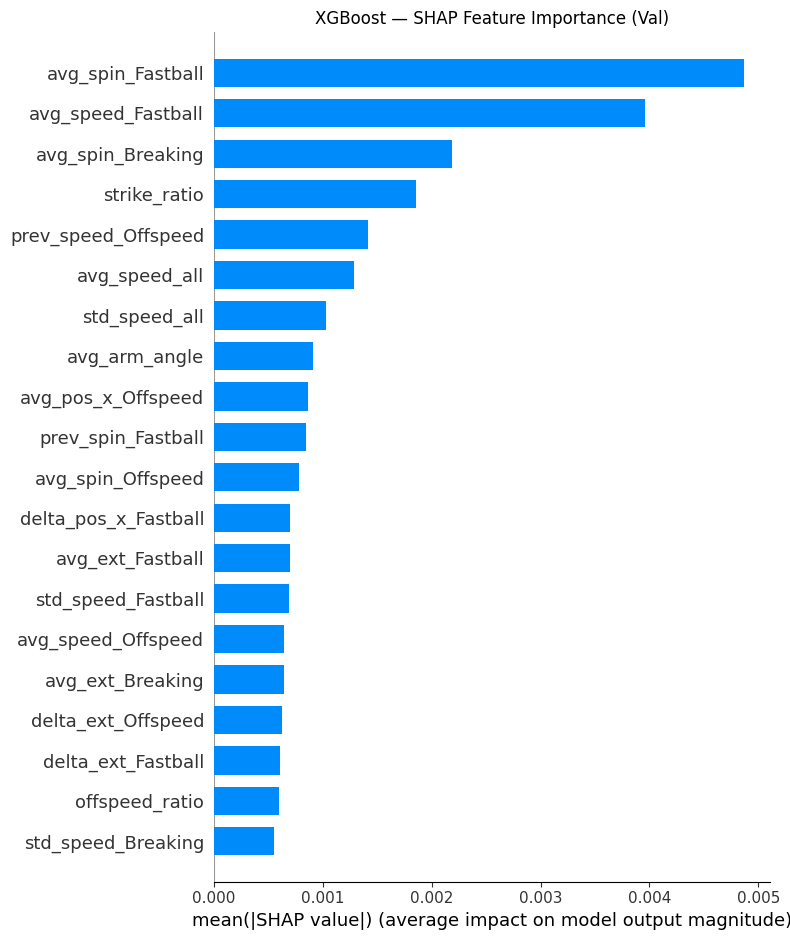

In [12]:
# ── XGBoost SHAP ───────────────────────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values   = explainer_xgb(X_val)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, plot_type='bar', show=False)
plt.title('XGBoost — SHAP Feature Importance (Val)')
plt.tight_layout()
plt.show()

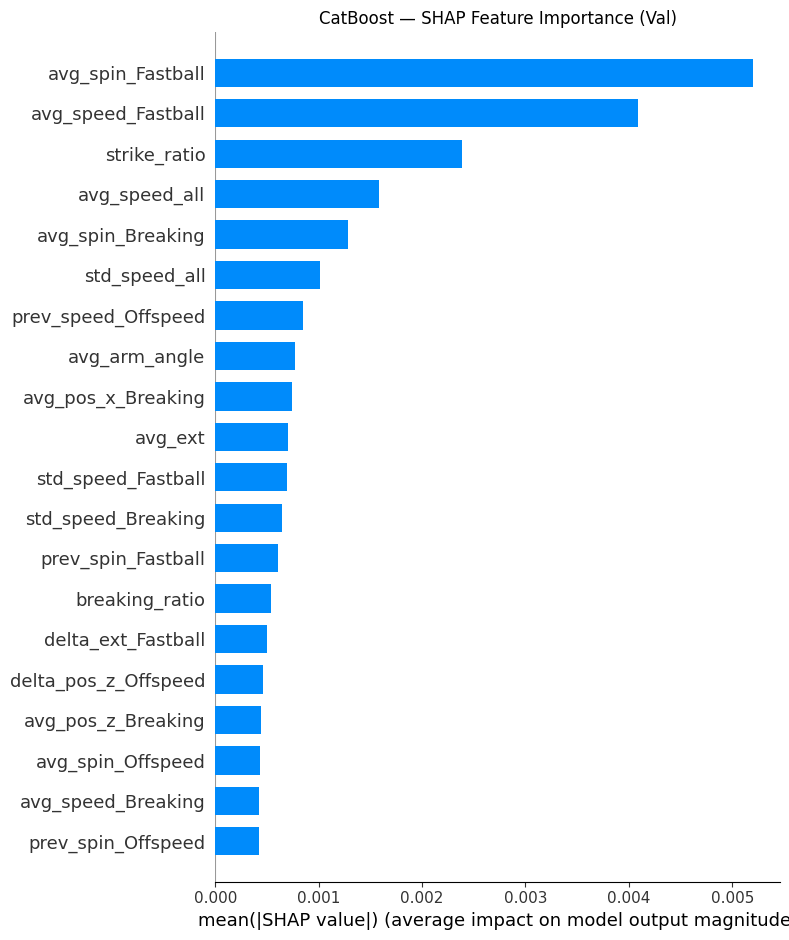

In [13]:
# ── CatBoost SHAP ──────────────────────────────────────────
explainer_cb = shap.TreeExplainer(cb_model)
shap_cb      = explainer_cb(X_val)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_cb, X_val, plot_type='bar', show=False)
plt.title('CatBoost — SHAP Feature Importance (Val)')
plt.tight_layout()
plt.show()

## 7. 예측값 분포 확인

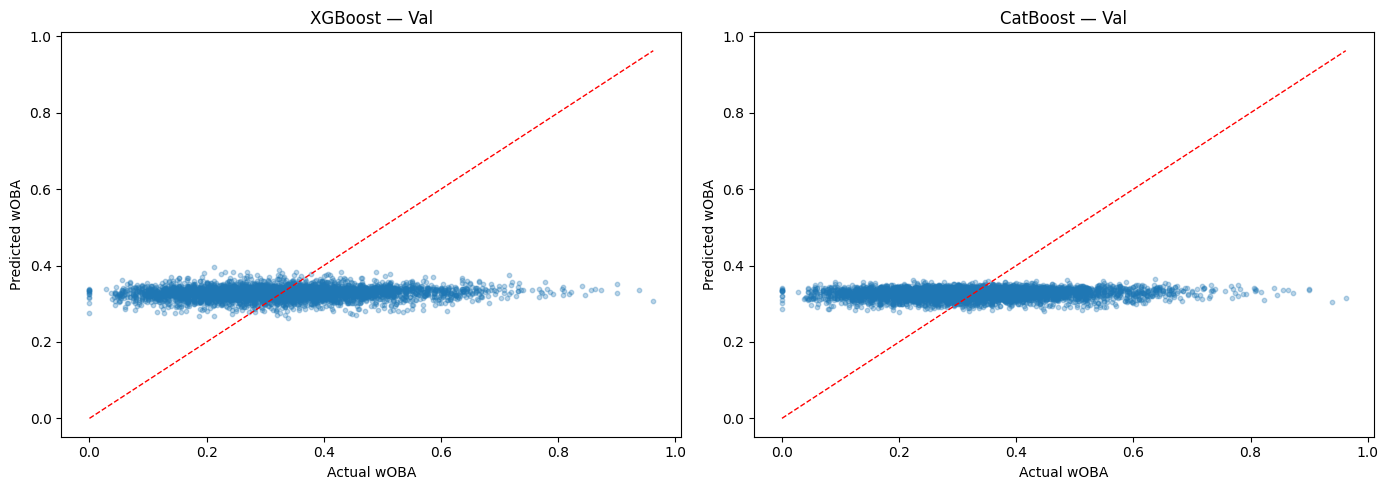

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('XGBoost', xgb_model), ('CatBoost', cb_model)]):
    pred = model.predict(X_val)
    ax.scatter(y_val, pred, alpha=0.3, s=10)
    lim = [min(y_val.min(), pred.min()), max(y_val.max(), pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_xlabel('Actual wOBA')
    ax.set_ylabel('Predicted wOBA')
    ax.set_title(f'{name} — Val')

plt.tight_layout()
plt.show()

## 8. 모델 저장

In [15]:
import joblib

xgb_path = os.path.join(MODEL_DIR, 'xgb_baseline.pkl')
cb_path  = os.path.join(MODEL_DIR, 'cb_baseline.pkl')

joblib.dump(xgb_model, xgb_path)
joblib.dump(cb_model,  cb_path)

print(f'XGBoost  저장 → {xgb_path}')
print(f'CatBoost 저장 → {cb_path}')

XGBoost  저장 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/xgb_baseline.pkl
CatBoost 저장 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/cb_baseline.pkl
